# B2: Model Training
**HelmTrack** — YOLOv8 Fine-tuning with MLflow Tracking

This notebook covers:
- Dataset verification
- 3 training runs with different configs
- MLflow experiment tracking
- Confusion matrix and metrics
- Best model selection

## 1. Imports

In [29]:
import os
import yaml
import shutil
import mlflow
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from ultralytics import YOLO, settings
%matplotlib inline

settings.update({'mlflow': False})

## 2. Verify Dataset

In [12]:
DATASET_PATH = Path("../data/helmet-detection")

with open(DATASET_PATH / "data.yaml") as f:
    config = yaml.safe_load(f)

CLASS_NAMES = config["names"]
print(f"Classes: {CLASS_NAMES}")

for split in ["train", "valid", "test"]:
    img_dir = DATASET_PATH / split / "images"
    count = len(list(img_dir.glob("*.jpg"))) + len(list(img_dir.glob("*.png"))) if img_dir.exists() else 0
    print(f"{split:8s}: {count} images")

Classes: ['Helmet', 'Motorbike', 'NoHelmet', 'PNumber']
train   : 1078 images
valid   : 308 images
test    : 154 images


## 3. Fix data.yaml Paths

In [13]:
abs_dataset = DATASET_PATH.resolve()

data_yaml = {
    "path": str(abs_dataset),
    "train": "train/images",
    "val":   "valid/images",
    "test":  "test/images",
    "nc":    config["nc"],
    "names": config["names"]
}

yaml_path = abs_dataset / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"data.yaml updated: {yaml_path}")

data.yaml updated: C:\Final Project\HelmTrack\data\helmet-detection\data.yaml


## 4. MLflow Setup

In [14]:
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("HelmTrack-YOLOv8")
print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: file:../mlruns


## 5. Training Runs

| Run | Model | Epochs |
|-----|-------|--------|
| 1   | YOLOv8n | 30 |
| 2   | YOLOv8n | 50 |
| 3   | YOLOv8s | 30 |

In [15]:
def train_run(run_name, model_size, epochs, imgsz=640):
    print(f"\nStarting: {run_name}  model={model_size}  epochs={epochs}")

    mlflow.set_experiment("HelmTrack-YOLOv8")
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({"model": model_size, "epochs": epochs, "imgsz": imgsz})

        model = YOLO(f"{model_size}.pt")
        results = model.train(
            data=str(yaml_path),
            epochs=epochs,
            imgsz=imgsz,
            project="../runs",
            name=run_name,
            exist_ok=True,
            verbose=False,
            workers=0
        )

        m = results.results_dict
        mlflow.log_metrics({
            "mAP50":     round(float(m.get("metrics/mAP50(B)",    0)), 4),
            "mAP50_95":  round(float(m.get("metrics/mAP50-95(B)", 0)), 4),
            "precision": round(float(m.get("metrics/precision(B)", 0)), 4),
            "recall":    round(float(m.get("metrics/recall(B)",    0)), 4),
        })

        best_pt = Path(f"../runs/{run_name}/weights/best.pt")
        if best_pt.exists():
            mlflow.log_artifact(str(best_pt), artifact_path="weights")

        print(f"mAP@50: {float(m.get('metrics/mAP50(B)', 0)):.4f}")
        return m, str(best_pt)

In [17]:
mlflow.end_run()

In [18]:
# Run 1 — YOLOv8n baseline
metrics1, weights1 = train_run("run1_yolov8n_30ep", "yolov8n", epochs=30)


Starting: run1_yolov8n_30ep  model=yolov8n  epochs=30
New https://pypi.org/project/ultralytics/8.4.50 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.49  Python-3.11.4 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Final Project\HelmTrack\data\helmet-detection\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, m

In [19]:
mlflow.end_run()

In [20]:
# Run 2 — YOLOv8n more epochs
metrics2, weights2 = train_run("run2_yolov8n_50ep", "yolov8n", epochs=50)


Starting: run2_yolov8n_50ep  model=yolov8n  epochs=50
New https://pypi.org/project/ultralytics/8.4.50 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.49  Python-3.11.4 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Final Project\HelmTrack\data\helmet-detection\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, m

In [21]:
mlflow.end_run()

In [22]:
# Run 3 — YOLOv8s larger model
metrics3, weights3 = train_run("run3_yolov8s_30ep", "yolov8s", epochs=30)


Starting: run3_yolov8s_30ep  model=yolov8s  epochs=30
New https://pypi.org/project/ultralytics/8.4.50 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.49  Python-3.11.4 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Final Project\HelmTrack\data\helmet-detection\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, m

In [23]:
mlflow.end_run()

## 6. Compare Runs

In [30]:
import pandas as pd

def load_metrics_from_csv(run_name):
    csv = Path(f"C:/Users/ASUS/runs/runs/{run_name}/results.csv")
    df = pd.read_csv(csv)
    df.columns = df.columns.str.strip()
    last = df.iloc[-1]
    return {
        "metrics/mAP50(B)":      last["metrics/mAP50(B)"],
        "metrics/mAP50-95(B)":   last["metrics/mAP50-95(B)"],
        "metrics/precision(B)":  last["metrics/precision(B)"],
        "metrics/recall(B)":     last["metrics/recall(B)"],
    }

metrics1 = load_metrics_from_csv("run1_yolov8n_30ep")
metrics2 = load_metrics_from_csv("run2_yolov8n_50ep")
metrics3 = load_metrics_from_csv("run3_yolov8s_30ep")
print("Metrics loaded from saved results.csv")


Metrics loaded from saved results.csv


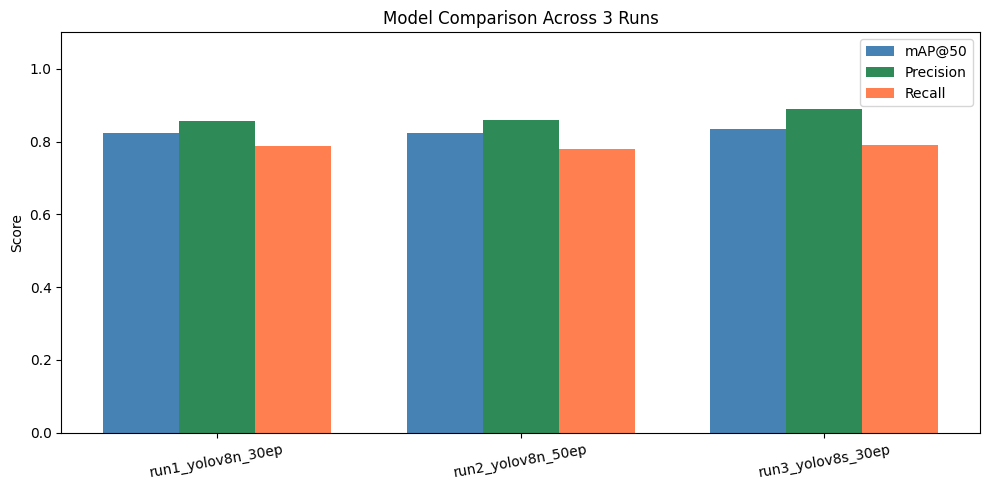

Best run: run3_yolov8s_30ep  mAP@50=0.8342


In [31]:
runs_data = [
    {"name": "run1_yolov8n_30ep", "metrics": metrics1},
    {"name": "run2_yolov8n_50ep", "metrics": metrics2},
    {"name": "run3_yolov8s_30ep", "metrics": metrics3},
]

labels = [r["name"] for r in runs_data]
map50  = [float(r["metrics"].get("metrics/mAP50(B)",    0)) for r in runs_data]
prec   = [float(r["metrics"].get("metrics/precision(B)", 0)) for r in runs_data]
rec    = [float(r["metrics"].get("metrics/recall(B)",    0)) for r in runs_data]

x = np.arange(len(labels))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, map50, w, label="mAP@50",   color="steelblue")
ax.bar(x,     prec,  w, label="Precision", color="seagreen")
ax.bar(x + w, rec,   w, label="Recall",    color="coral")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Model Comparison Across 3 Runs")
ax.legend()
plt.tight_layout()
plt.savefig("run_comparison.png", dpi=150)
plt.show()

best_idx = int(np.argmax(map50))
print(f"Best run: {labels[best_idx]}  mAP@50={map50[best_idx]:.4f}")

## 7. Save Best Model

In [26]:
from pathlib import Path

best_pt = Path("../model/best.pt")
assert best_pt.exists(), f"Model not found at {best_pt}"
print(f"Best model ready at: {best_pt} ({best_pt.stat().st_size // 1024} KB)")


Best model ready at: ..\model\best.pt (21969 KB)


## 8. Confusion Matrix

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

conf_path = Path(r"confusion_matrix.png")

if conf_path.exists():
    img = mpimg.imread(str(conf_path))
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion Matrix - run3_yolov8s_30ep")
    plt.tight_layout()
    plt.show()
else:
    print(f"Not found: {conf_path}")


Not found: confusion_matrix.png


## 9. Launch MLflow UI

Run in terminal:
```
mlflow ui --backend-store-uri file:../mlruns
```
Then open `http://127.0.0.1:5000` and screenshot the runs table for B4.